# (Adaptive) Retail Demand Forecasting: Time Series Analysis, Temporal Feature Engineering & Multi-Model Forecast Comparison

## Part 01 — Time Series EDA

This project uses the Kaggle Store Sales dataset from Corporación Favorita to study retail demand forecasting.

The first stage focuses on understanding the historical sales patterns before building forecasting models. The analysis covers trend, weekly and annual seasonality, stationarity, autocorrelation, holidays, and promotions.

The goal is to identify the main time-dependent patterns that will guide the forecasting approach used in later stages.

In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf

## 1. Load the Data

The main historical sales data is stored in `train.csv`. Supporting datasets containing holidays, oil prices, transactions, and store information will be used where relevant during the analysis and later modeling stages.

In [2]:
train = pd.read_csv("../data/raw/train.csv")
holidays = pd.read_csv("../data/raw/holidays_events.csv")
oil = pd.read_csv("../data/raw/oil.csv")
transactions = pd.read_csv("../data/raw/transactions.csv")
stores = pd.read_csv("../data/raw/stores.csv")
test = pd.read_csv("../data/raw/test.csv")

In [3]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


## 2. Prepare the Date Columns

The date column is converted to datetime so that the data can be analyzed in chronological order and time-based features can be created later.

In [4]:
train["date"] = pd.to_datetime(train["date"])
holidays["date"] = pd.to_datetime(holidays["date"])
oil["date"] = pd.to_datetime(oil["date"])
transactions["date"] = pd.to_datetime(transactions["date"])
test["date"] = pd.to_datetime(test["date"])

## 3. Basic Dataset Audit

Before analyzing the time series, the structure, date range, missing values, and duplicate records are checked.

In [5]:
print("Shape:", train.shape)
print("Date range:", train["date"].min(), "to", train["date"].max())
print("Unique dates:", train["date"].nunique())
print("Missing values:")
print(train.isnull().sum())
print("Duplicate rows:", train.duplicated().sum())

Shape: (3000888, 6)
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Unique dates: 1684
Missing values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64
Duplicate rows: 0


In [6]:
train.dtypes

id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
dtype: object

In [7]:
train.describe(include="all")

,id,date,store_nbr,family,sales,onpromotion
count,3.000888e+06,3000888,3.000888e+06,3000888,3.000888e+06,3.000888e+06
unique,NaN,NaN,NaN,33,NaN,NaN
top,NaN,NaN,NaN,AUTOMOTIVE,NaN,NaN
freq,NaN,NaN,NaN,90936,NaN,NaN
mean,1.500444e+06,2015-04-24 08:27:04.703088384,2.750000e+01,NaN,3.577757e+02,2.602770e+00
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,NaN,0.000000e+00,0.000000e+00
25%,7.502218e+05,2014-02-26 18:00:00,1.400000e+01,NaN,0.000000e+00,0.000000e+00
50%,1.500444e+06,2015-04-24 12:00:00,2.750000e+01,NaN,1.100000e+01,0.000000e+00
75%,2.250665e+06,2016-06-19 06:00:00,4.100000e+01,NaN,1.958473e+02,0.000000e+00
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,NaN,1.247170e+05,7.410000e+02


## 4. Create the Daily Sales Series

The original dataset contains sales for individual stores and product families.

For the initial time series analysis, sales are aggregated across all stores and product families for each date. This creates one daily sales series that can be used to study overall retail demand patterns.

The more detailed store and product-level data will be used later when building the forecasting features and machine-learning model.

In [8]:
daily_sales = (
    train.groupby("date", as_index=False)
    .agg(
        sales=("sales", "sum"),
        onpromotion=("onpromotion", "sum")
    )
)
daily_sales.head()

,date,sales,onpromotion
0,2013-01-01,2511.618999,0
1,2013-01-02,496092.417944,0
2,2013-01-03,361461.231124,0
3,2013-01-04,354459.677093,0
4,2013-01-05,477350.121229,0


In [9]:
daily_sales.shape

(1684, 3)

## 5. Check for Missing Dates

A time series should have a clear and consistent time index. Missing calendar dates are checked before performing decomposition and autocorrelation analysis.

In [10]:
full_date_range = pd.date_range(
    start=daily_sales["date"].min(),
    end=daily_sales["date"].max(),
    freq="D"
)

missing_dates = full_date_range.difference(daily_sales["date"])

print("Number of missing dates:", len(missing_dates))
print("Missing dates:")
print(missing_dates)

Number of missing dates: 4
Missing dates:
DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)


## 6. Sales Summary

The daily sales series is summarized to understand its overall scale and variability before investigating trends and seasonal patterns.

In [11]:
daily_sales["sales"].describe()

count    1.684000e+03
mean     6.375564e+05
std      2.344102e+05
min      2.511619e+03
25%      4.427115e+05
50%      6.321889e+05
75%      7.859455e+05
max      1.463084e+06
Name: sales, dtype: float64

## 7. Sales Over Time

The overall daily sales trend is visualized to identify long-term changes, major fluctuations, and potential seasonality.

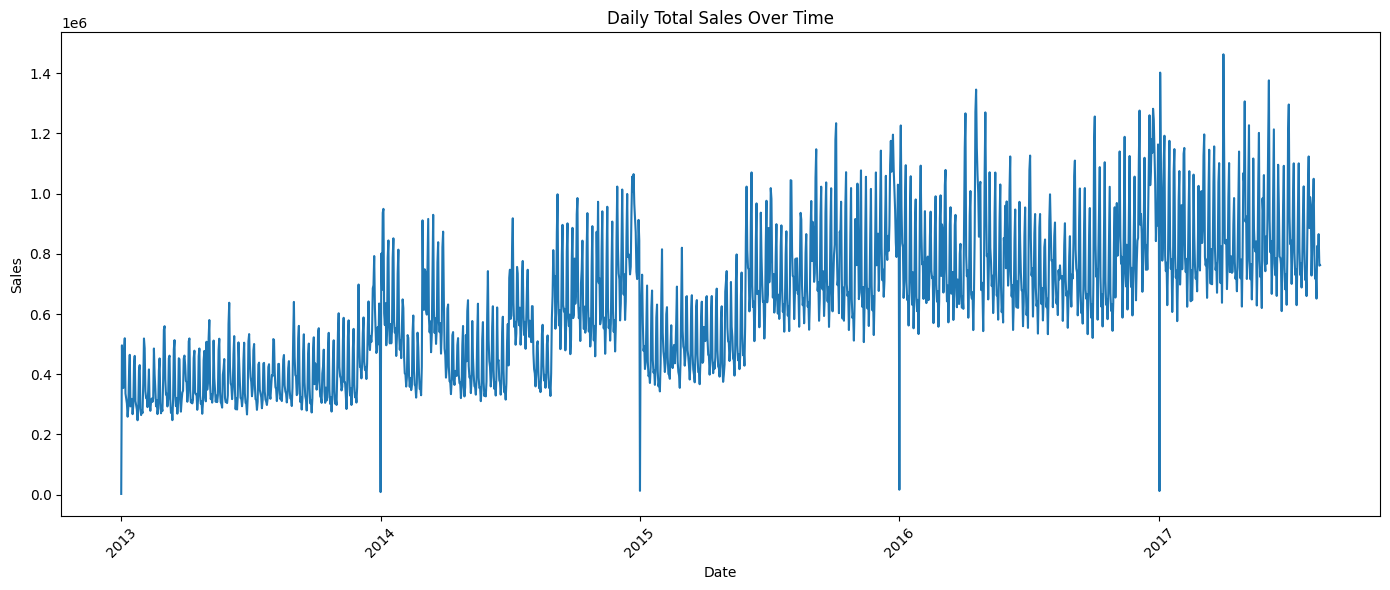

In [12]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"]
)

plt.title("Daily Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../images/1_daily_sales_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Weekly Seasonality

Daily sales are compared across the seven days of the week to identify recurring weekly patterns.

In [13]:
daily_sales["day_of_week"] = daily_sales["date"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = (
    daily_sales.groupby("day_of_week")["sales"]
    .mean()
    .reindex(weekday_order)
)

weekday_sales

day_of_week
Monday       617542.713052
Tuesday      569926.087922
Wednesday    593244.553472
Thursday     505269.201115
Friday       579574.361085
Saturday     772205.593943
Sunday       825218.121579
Name: sales, dtype: float64

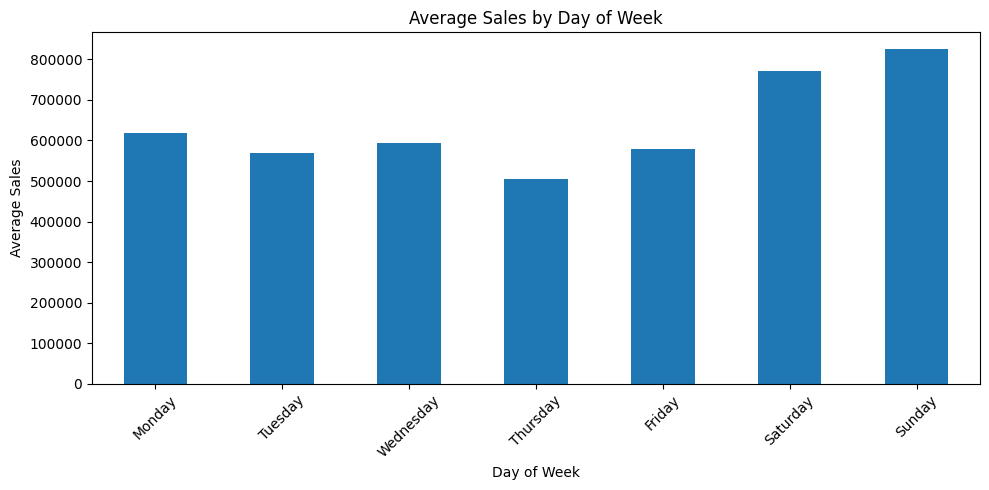

In [14]:
plt.figure(figsize=(10, 5))

weekday_sales.plot(kind="bar")

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../images/2_sales_by_day_of_week.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Annual Seasonality

Average sales are compared across the months of the year to check whether demand follows a recurring yearly pattern.

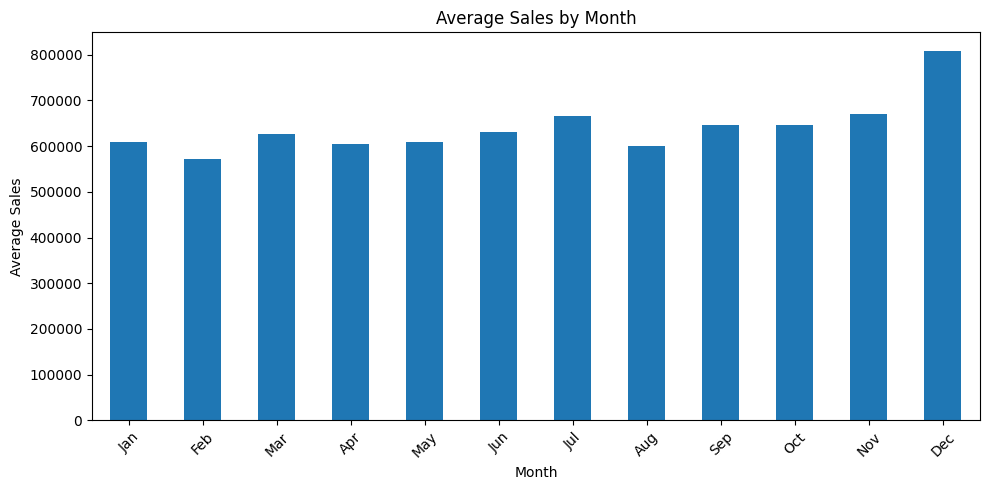

In [15]:
daily_sales["month"] = daily_sales["date"].dt.month

monthly_sales = daily_sales.groupby("month")["sales"].mean()

plt.figure(figsize=(10, 5))

monthly_sales.plot(kind="bar")

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(
    range(12),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    rotation=45
)

plt.tight_layout()

plt.savefig(
    "../images/3_average_sales_by_month.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
promotion_correlation = daily_sales["sales"].corr(
    daily_sales["onpromotion"]
)

print("Correlation between sales and promotions:", promotion_correlation)

Correlation between sales and promotions: 0.5749429166866837


## 10. Promotion Effects

The relationship between the amount of promoted product activity and total daily sales is examined to determine whether promotions are associated with changes in demand.

In [17]:
promotion_summary = (
    daily_sales.groupby(
        pd.qcut(
            daily_sales["onpromotion"],
            q=5,
            duplicates="drop"
        )
    )["sales"]
    .agg(["count", "mean"])
)

promotion_summary

C:\Users\franc\AppData\Local\Temp\ipykernel_34096\4113700794.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_sales.groupby(


,count,mean
onpromotion,,
"(-0.001, 970.6]",674,458355.238320
"(970.6, 4278.0]",337,701435.157831
"(4278.0, 9611.0]",336,736658.319830
"(9611.0, 26861.0]",337,833272.041316


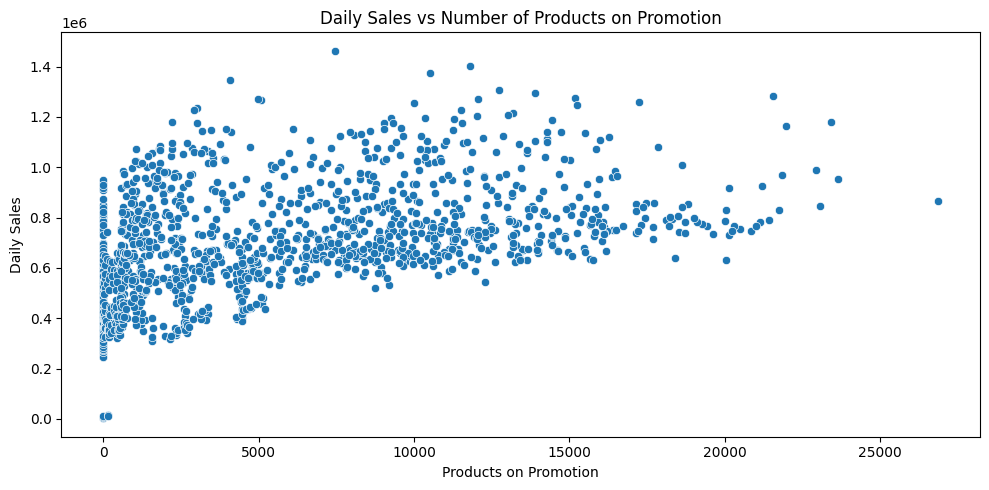

In [18]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=daily_sales,
    x="onpromotion",
    y="sales"
)

plt.title("Daily Sales vs Number of Products on Promotion")
plt.xlabel("Products on Promotion")
plt.ylabel("Daily Sales")
plt.tight_layout()

plt.savefig("../images/4_sales_vs_promotions.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Holiday Effects

Holiday and event dates are examined to determine whether sales behavior differs on days associated with holidays and events.

In [19]:
holiday_dates = set(
    holidays.loc[
        holidays["transferred"] == False,
        "date"
    ]
)

daily_sales["is_holiday"] = daily_sales["date"].isin(holiday_dates)

In [20]:
holiday_summary = (
    daily_sales.groupby("is_holiday")["sales"]
    .agg(["count", "mean", "median"])
)

holiday_summary

,count,mean,median
is_holiday,,,
False,1441,627095.802719,624910.026095
True,243,699588.067841,685673.074740


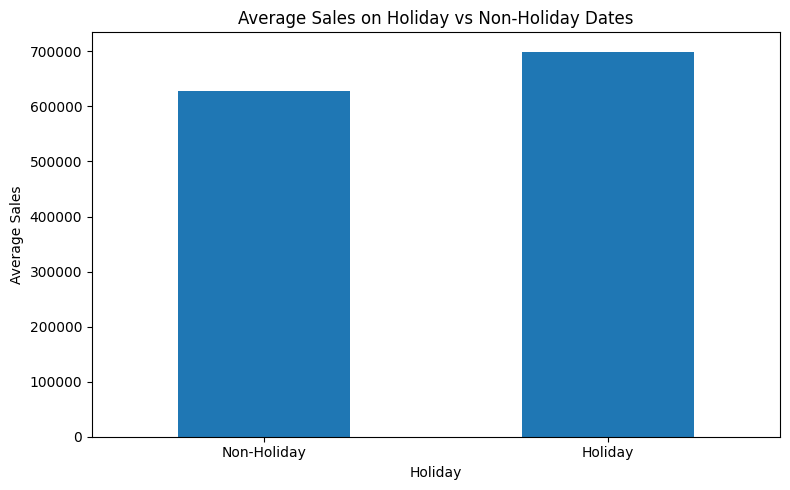

In [21]:
plt.figure(figsize=(8, 5))

holiday_summary["mean"].plot(kind="bar")

plt.title("Average Sales on Holiday vs Non-Holiday Dates")
plt.xlabel("Holiday")
plt.ylabel("Average Sales")
plt.xticks(
    [0, 1],
    ["Non-Holiday", "Holiday"],
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "../images/5_holiday_sales_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 12. Prepare the Series for Time Series Analysis

Four Christmas dates are missing from the aggregated sales data. These missing dates are retained as missing in the source data rather than treated as zero sales.

For statistical decomposition and autocorrelation analysis, the missing observations are temporarily interpolated so that the time series has a continuous daily index. This is only for exploratory analysis and does not represent new observed sales data.

In [22]:
sales_series = (
    daily_sales
    .set_index("date")["sales"]
    .asfreq("D")
)

sales_series = sales_series.interpolate()

In [23]:
sales_series.isna().sum()

np.int64(0)

## 13. STL Decomposition

STL decomposition separates the time series into trend, seasonal, and residual components.

Two seasonal periods are examined:

- 7 days for weekly seasonality
- 365 days for annual seasonality

This helps identify whether the observed sales patterns are driven mainly by long-term trend, recurring weekly behavior, annual patterns, or irregular variation.

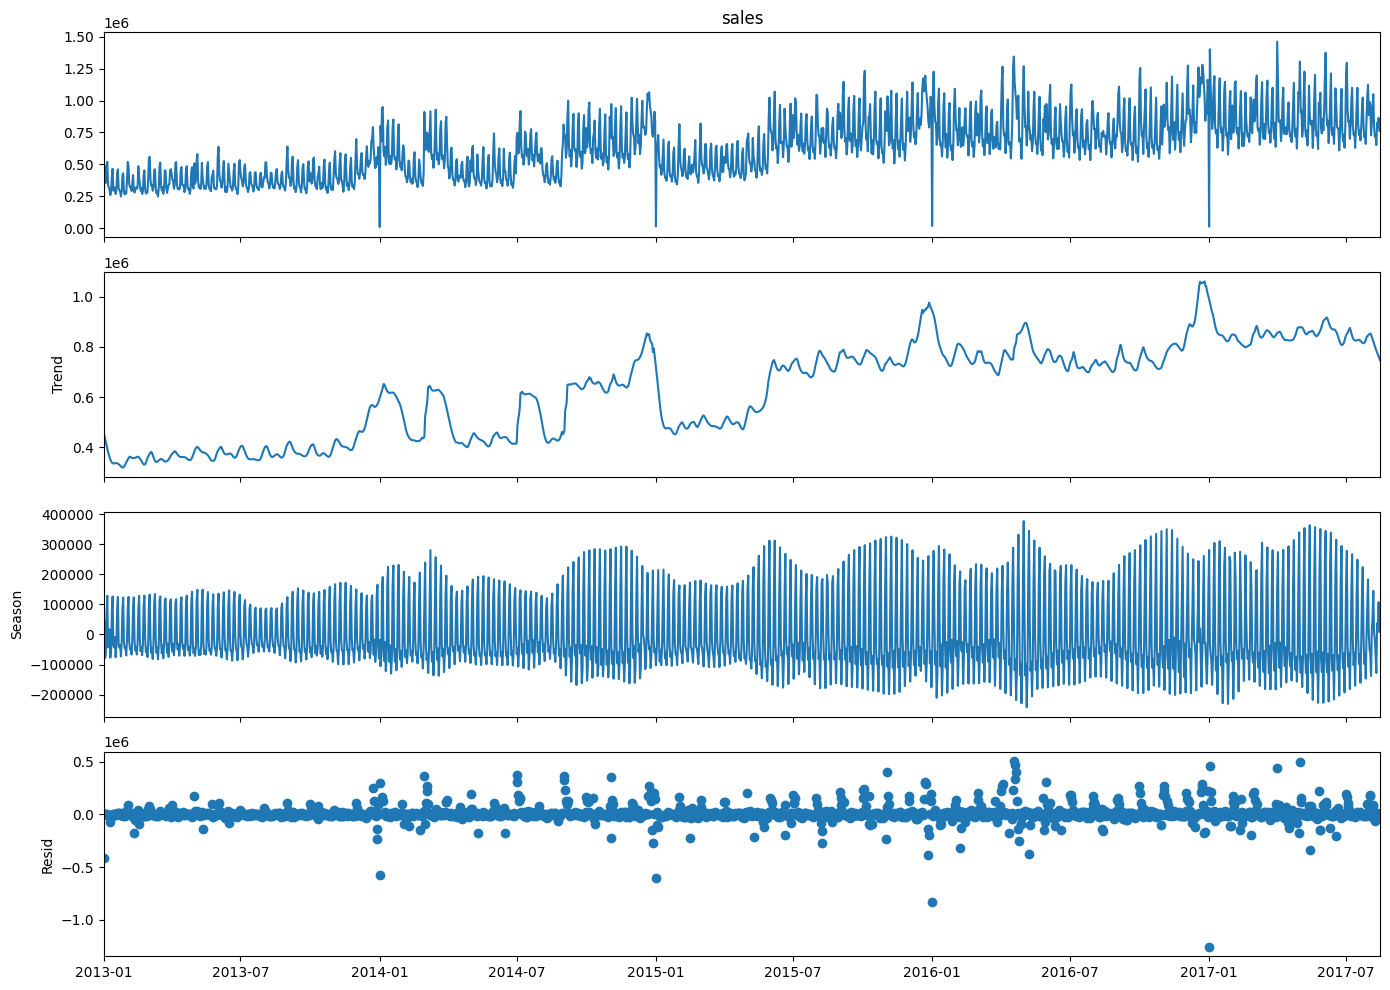

In [24]:
stl_weekly = STL(
    sales_series,
    period=7,
    robust=True
)

result_weekly = stl_weekly.fit()

fig = result_weekly.plot()
fig.set_size_inches(14, 10)

plt.tight_layout()
plt.savefig("../images/6_stl_weekly.png", dpi=300, bbox_inches="tight")
plt.show()

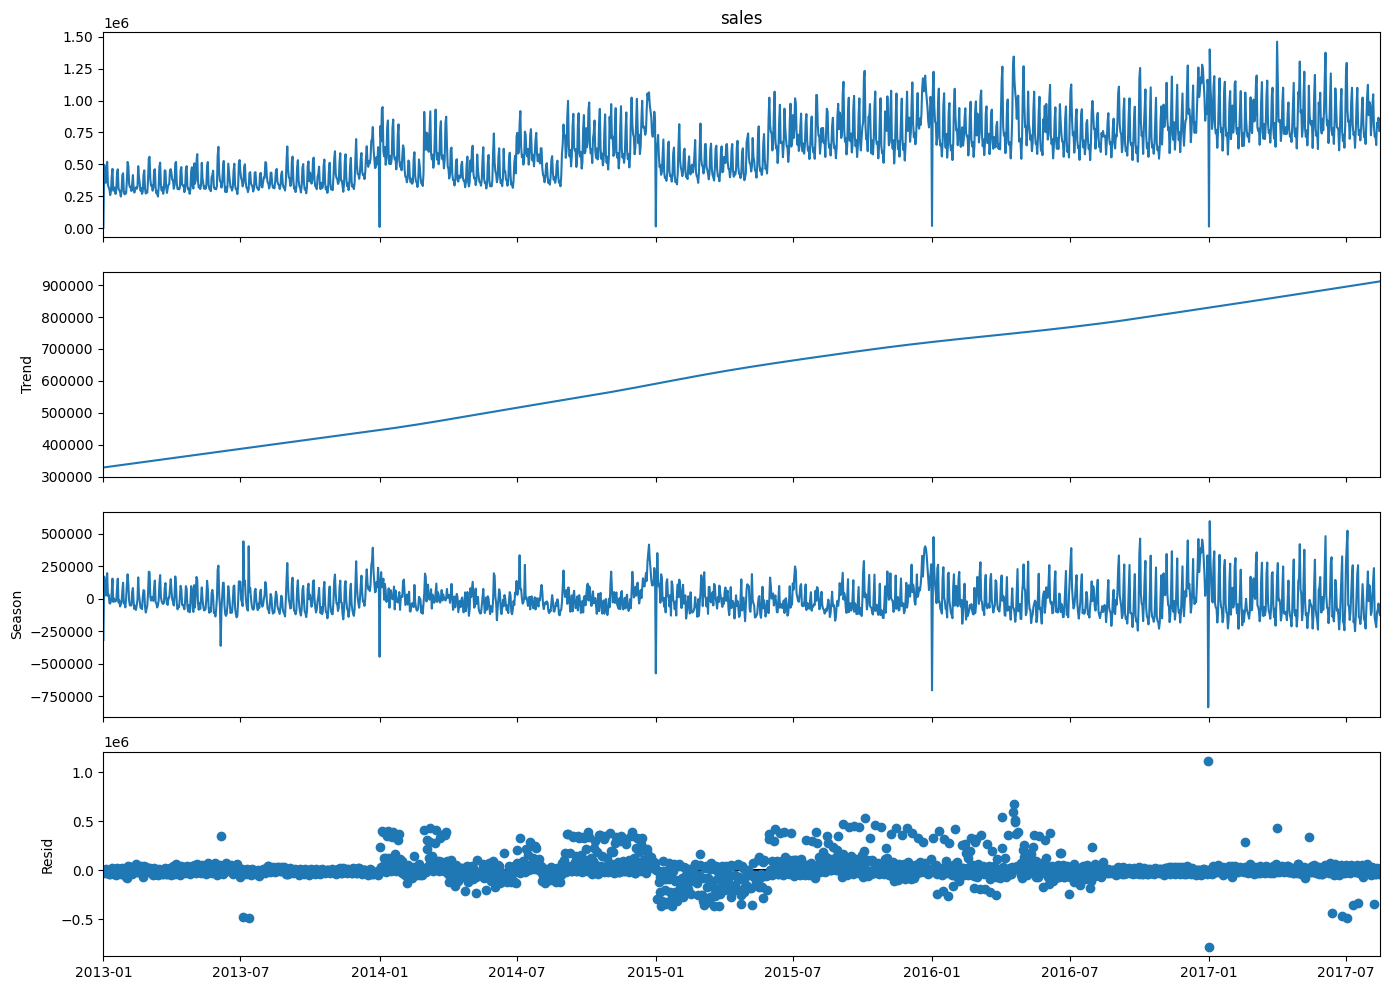

In [25]:
stl_annual = STL(
    sales_series,
    period=365,
    robust=True
)

result_annual = stl_annual.fit()

fig = result_annual.plot()
fig.set_size_inches(14, 10)

plt.tight_layout()
plt.savefig("../images/7_stl_annual.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. Stationarity Testing

Stationarity testing is used to determine whether the statistical properties of the sales series remain stable over time.

The Augmented Dickey-Fuller (ADF) test uses the null hypothesis that the series has a unit root and is non-stationary.

In [26]:
adf_result = adfuller(sales_series, autolag="AIC")

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -2.621079341975962
p-value: 0.0887183855488376
Critical Values:
1%: -3.434283579780684
5%: -2.863277451883613
10%: -2.5676949772294817


C:\Users\franc\AppData\Local\Temp\ipykernel_34096\1053341458.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(sales_series, autolag="AIC")


The KPSS test is also used because it approaches stationarity from the opposite direction.

The KPSS null hypothesis is that the series is stationary around a constant level.

In [27]:
kpss_result = kpss(
    sales_series,
    regression="c",
    nlags="auto"
)

print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Critical Values:")

for key, value in kpss_result[3].items():
    print(f"{key}: {value}")

KPSS Statistic: 5.731005263379233
p-value: 0.01
Critical Values:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


C:\Users\franc\AppData\Local\Temp\ipykernel_34096\3223716974.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_result = kpss(
C:\Users\franc\AppData\Local\Temp\ipykernel_34096\3223716974.py:1: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  kpss_result = kpss(


## 15. First Difference

The first difference is calculated to remove part of the long-term trend and test whether the resulting series is closer to stationary behavior.

In [28]:
sales_diff = sales_series.diff().dropna()

In [29]:
adf_diff = adfuller(
    sales_diff,
    autolag="AIC"
)

print("ADF Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])

ADF Statistic: -11.363939717850094
p-value: 9.326101119330917e-21


C:\Users\franc\AppData\Local\Temp\ipykernel_34096\3460627849.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_diff = adfuller(


In [30]:
kpss_diff = kpss(
    sales_diff,
    regression="c",
    nlags="auto"
)

print("KPSS Statistic:", kpss_diff[0])
print("p-value:", kpss_diff[1])

KPSS Statistic: 0.0649360905063961
p-value: 0.1


C:\Users\franc\AppData\Local\Temp\ipykernel_34096\1869661528.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_diff = kpss(
C:\Users\franc\AppData\Local\Temp\ipykernel_34096\1869661528.py:1: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  kpss_diff = kpss(


## 16. Autocorrelation Function (ACF)

The ACF measures how strongly the current sales value is related to previous values at different time lags.

For daily retail data, particular attention is given to lag 7 and other multiples of 7 because they can indicate weekly seasonality.

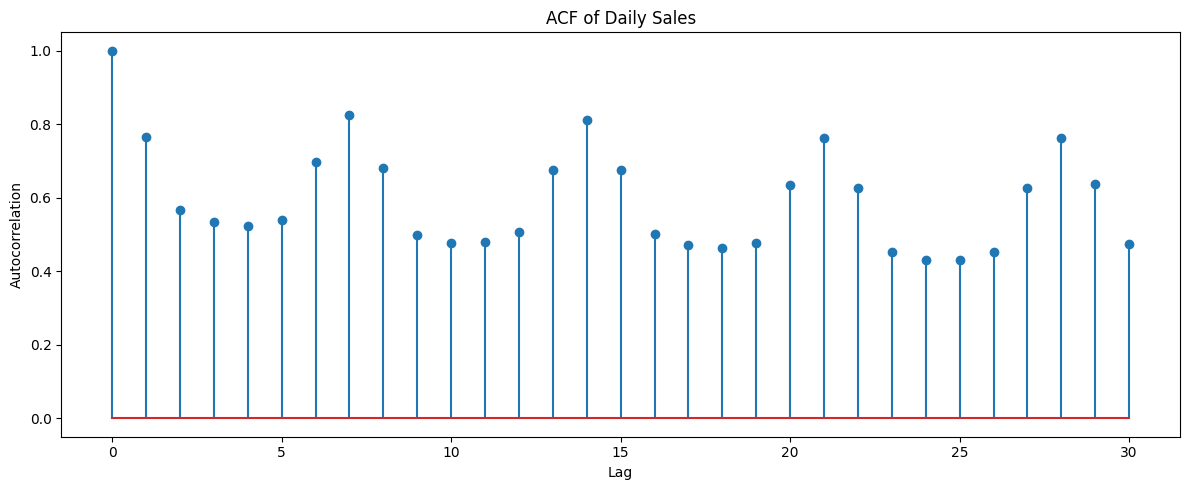

In [31]:
acf_values = acf(
    sales_series,
    nlags=30,
    fft=True
)

plt.figure(figsize=(12, 5))

plt.stem(
    range(len(acf_values)),
    acf_values
)

plt.title("ACF of Daily Sales")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()

plt.savefig("../images/8_acf_daily_sales.png", dpi=300, bbox_inches="tight")
plt.show()

## 17. Partial Autocorrelation Function (PACF)

The PACF measures the relationship between the current value and a specific lag after accounting for the effects of shorter lags.

PACF can help identify useful lag structures for later time series models.

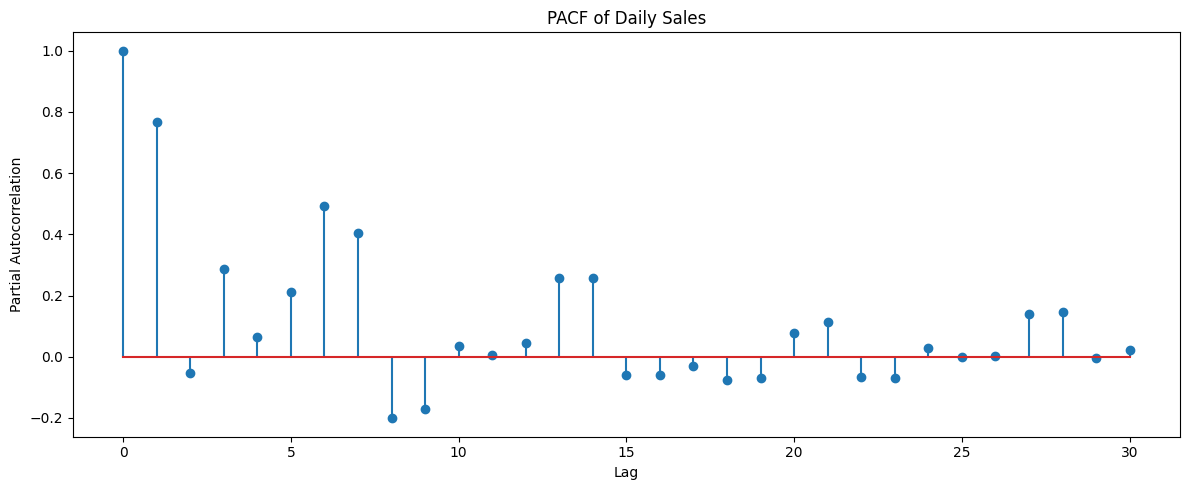

In [32]:
pacf_values = pacf(
    sales_series,
    nlags=30,
    method="ywm"
)

plt.figure(figsize=(12, 5))

plt.stem(
    range(len(pacf_values)),
    pacf_values
)

plt.title("PACF of Daily Sales")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.tight_layout()

plt.savefig("../images/9_pacf_daily_sales.png", dpi=300, bbox_inches="tight")
plt.show()

## Part 01 Findings

The initial time series analysis shows that retail sales contain clear temporal structure.

Daily sales display a strong weekly pattern, with average sales generally higher on Saturdays and Sundays than on weekdays. This indicates that weekly seasonality will need to be considered in the forecasting models.

The STL decomposition provides evidence of both recurring seasonal behavior and longer-term changes in the overall sales level. Examining both 7-day and 365-day seasonal periods helps separate weekly patterns from longer-term seasonal effects.

The raw sales series is not stationary. The ADF test produced a p-value of approximately 0.0897, while the KPSS test produced a statistic of approximately 5.7377 with a p-value of 0.01. These results provide evidence that the original series should not be treated as stationary.

After first differencing, the ADF test strongly rejected the unit-root hypothesis and the KPSS test no longer indicated non-stationarity. This suggests that differencing may be useful for statistical forecasting approaches that require a stationary series.

The ACF showed strong autocorrelation, including a strong relationship around lag 7, which supports the presence of weekly seasonality. The PACF also showed significant relationships at several early lags.

Promotion activity was positively associated with daily sales in the historical data. The correlation between total daily sales and the number of products on promotion was approximately 0.575. This suggests that promotion information may be useful as a forecasting feature.

Holiday dates also showed different average sales behavior from non-holiday dates. Average sales on observed holiday dates were higher than the average on non-holiday dates in this dataset, suggesting that holiday indicators may provide useful forecasting information.

The main conclusion from this stage is that the retail sales series contains trend, seasonality, autocorrelation, and calendar-related effects. These characteristics justify the use of specialized time series validation and temporal features in the later forecasting stages.

## Leakage Consideration

Time series forecasting differs from ordinary machine learning because future observations cannot be used to make predictions about earlier dates.

All future modeling stages will preserve chronological order. Lag features, rolling statistics, model validation, and final forecasting will be constructed so that information from the future is never used to predict the past.

# Part 02 — Temporal Feature Engineering & Leakage Prevention

The second stage converts the historical sales series into forecasting features.

The features include lagged sales, rolling statistics, Fourier terms, calendar information, holiday and event indicators, and promotion indicators.

All target-based features are created using past observations only so that future information does not leak into the training data.

## 18. Understanding Look-Ahead Bias

Time series features must be created differently from ordinary machine learning features.

For a prediction made for a particular day, information from future days would not be available.

For example, the sales value for tomorrow cannot be used to create a feature for today.

Lag features and rolling statistics must therefore use only previous observations.

This prevents look-ahead bias and makes the later model evaluation more realistic.

In [33]:
feature_data = (
    daily_sales[["date", "sales", "onpromotion"]]
    .copy()
)

feature_data = (
    feature_data
    .set_index("date")
    .reindex(
        pd.date_range(
            feature_data["date"].min(),
            feature_data["date"].max(),
            freq="D"
        )
    )
    .rename_axis("date")
    .reset_index()
)

feature_data.head()

,date,sales,onpromotion
0,2013-01-01,2511.618999,0.0
1,2013-01-02,496092.417944,0.0
2,2013-01-03,361461.231124,0.0
3,2013-01-04,354459.677093,0.0
4,2013-01-05,477350.121229,0.0


## 19. Lag Features

Lag features use previous sales values as predictors.

A lag of 1 represents the previous day's sales.

A lag of 7 represents sales from seven calendar days earlier.

Several lag lengths are created to capture short-term and weekly demand patterns.

In [34]:
lag_periods = [1, 7, 14, 28]

for lag in lag_periods:
    feature_data[f"lag_{lag}"] = feature_data["sales"].shift(lag)

In [35]:
feature_data[
    ["date", "sales", "lag_1", "lag_7", "lag_14", "lag_28"]
].tail(15)

,date,sales,lag_1,lag_7,lag_14,lag_28
1673,2017-08-01,9.885278e+05,8.858568e+05,7.135816e+05,7.301337e+05,8.323593e+05
1674,2017-08-02,9.647120e+05,9.885278e+05,7.406530e+05,7.679788e+05,8.443016e+05
1675,2017-08-03,7.280685e+05,9.647120e+05,6.598498e+05,6.882881e+05,7.002720e+05
1676,2017-08-04,8.277757e+05,7.280685e+05,8.350997e+05,7.824183e+05,8.057923e+05
1677,2017-08-05,9.656937e+05,8.277757e+05,1.032311e+06,9.329020e+05,9.983472e+05
1678,2017-08-06,1.049559e+06,9.656937e+05,1.123752e+06,1.024289e+06,1.100833e+06
1679,2017-08-07,7.974650e+05,1.049559e+06,8.858568e+05,8.165643e+05,8.041589e+05
1680,2017-08-08,7.177663e+05,7.974650e+05,9.885278e+05,7.135816e+05,7.305348e+05
1681,2017-08-09,7.341397e+05,7.177663e+05,9.647120e+05,7.406530e+05,7.488000e+05
1682,2017-08-10,6.513869e+05,7.341397e+05,7.280685e+05,6.598498e+05,6.296514e+05


In [36]:
feature_data["sales"].shift(1)

0                 NaN
1         2511.618999
2       496092.417944
3       361461.231124
4       354459.677093
            ...      
1683    651386.911970
1684    826373.722022
1685    792630.535079
1686    865639.677471
1687    760922.406081
Name: sales, Length: 1688, dtype: float64

In [37]:
feature_data[
    feature_data["date"] == "2017-08-15"
][
    ["date", "sales", "lag_1", "lag_7"]
]

,date,sales,lag_1,lag_7
1687,2017-08-15,762661.935939,760922.406081,717766.349106


## 20. Rolling Window Features

Rolling statistics summarize recent historical demand.

The rolling calculations are shifted by one day before calculating the window.

This is important because the current day's sales must not be included in a feature used to predict the current day.

Rolling means capture recent demand levels, while rolling standard deviations capture recent sales variability.

In [38]:
rolling_windows = [7, 14, 28]

for window in rolling_windows:
    feature_data[f"rolling_mean_{window}"] = (
        feature_data["sales"]
        .shift(1)
        .rolling(window=window, min_periods=window)
        .mean()
    )

    feature_data[f"rolling_std_{window}"] = (
        feature_data["sales"]
        .shift(1)
        .rolling(window=window, min_periods=window)
        .std()
    )

In [39]:
feature_data[
    [
        "date",
        "sales",
        "rolling_mean_7",
        "rolling_mean_14",
        "rolling_mean_28",
        "rolling_std_7",
        "rolling_std_14",
        "rolling_std_28"
    ]
].tail(15)

,date,sales,rolling_mean_7,rolling_mean_14,rolling_mean_28,rolling_std_7,rolling_std_14,rolling_std_28
1673,2017-08-01,9.885278e+05,855872.052943,838119.881408,842229.464914,171351.418824,142670.680816,140756.606358
1674,2017-08-02,9.647120e+05,895150.071599,856576.599570,847806.910528,164681.251158,144330.393506,143419.889984
1675,2017-08-03,7.280685e+05,927158.496154,870628.973711,852107.282061,150840.558666,144617.675700,145106.200940
1676,2017-08-04,8.277757e+05,936904.018736,873470.432088,853100.013318,131678.476015,141107.648536,144120.697455
1677,2017-08-05,9.656937e+05,935857.733582,876710.245438,853885.134172,132647.737339,139366.246775,143913.165581
1678,2017-08-06,1.049559e+06,926340.988547,879052.502853,852718.936225,126836.856834,140652.895481,142827.370098
1679,2017-08-07,7.974650e+05,915741.943736,880857.533070,850887.716293,109506.905364,142805.791701,139825.577726
1680,2017-08-08,7.177663e+05,903114.532729,879493.292836,850648.648535,118272.804692,143556.494378,139914.126217
1681,2017-08-09,7.341397e+05,864434.330715,879792.201157,850192.633586,129432.196546,143188.350004,140340.265314
1682,2017-08-10,6.513869e+05,831495.424709,879326.960431,849669.050661,128997.702630,143684.930388,140759.274204


In [40]:
feature_data["sales"].rolling(7).mean()

0                 NaN
1                 NaN
2                 NaN
3                 NaN
4                 NaN
            ...      
1683    820340.633670
1684    795617.331469
1685    769343.119068
1686    764122.753677
1687    770536.408939
Name: sales, Length: 1688, dtype: float64

In [41]:
feature_data["sales"].shift(1).rolling(7).mean()

0                 NaN
1                 NaN
2                 NaN
3                 NaN
4                 NaN
            ...      
1683    820540.914257
1684    820340.633670
1685    795617.331469
1686    769343.119068
1687    764122.753677
Name: sales, Length: 1688, dtype: float64

## 21. Calendar Features

Calendar features capture recurring patterns caused by the calendar.

These features are available from the date itself, so they do not require future sales information.

In [42]:
feature_data["day_of_week"] = feature_data["date"].dt.dayofweek
feature_data["day_of_month"] = feature_data["date"].dt.day
feature_data["week_of_year"] = (
    feature_data["date"].dt.isocalendar().week.astype(int)
)
feature_data["month"] = feature_data["date"].dt.month
feature_data["quarter"] = feature_data["date"].dt.quarter
feature_data["year"] = feature_data["date"].dt.year
feature_data["is_weekend"] = (
    feature_data["day_of_week"] >= 5
).astype(int)

In [43]:
feature_data[
    [
        "date",
        "day_of_week",
        "day_of_month",
        "week_of_year",
        "month",
        "quarter",
        "year",
        "is_weekend"
    ]
].head(10)

,date,day_of_week,day_of_month,week_of_year,month,quarter,year,is_weekend
0,2013-01-01,1,1,1,1,1,2013,0
1,2013-01-02,2,2,1,1,1,2013,0
2,2013-01-03,3,3,1,1,1,2013,0
3,2013-01-04,4,4,1,1,1,2013,0
4,2013-01-05,5,5,1,1,1,2013,1
5,2013-01-06,6,6,1,1,1,2013,1
6,2013-01-07,0,7,2,1,1,2013,0
7,2013-01-08,1,8,2,1,1,2013,0
8,2013-01-09,2,9,2,1,1,2013,0
9,2013-01-10,3,10,2,1,1,2013,0


## 22. Holiday and Event Features

Holiday and event information is added to the daily forecasting data.

Only holiday information known for the corresponding date is used.

The source contains different event types and geographic scopes, so simple indicators are created for whether an event occurs and whether the event is national or local.

In [44]:
holiday_info = holidays[
    holidays["transferred"] == False
].copy()

holiday_info["event_count"] = 1

holiday_info["is_national_holiday"] = (
    holiday_info["locale"] == "National"
).astype(int)

holiday_info["is_local_holiday"] = (
    holiday_info["locale"] == "Local"
).astype(int)

holiday_daily = (
    holiday_info
    .groupby("date")
    .agg(
        holiday_event_count=("event_count", "sum"),
        is_national_holiday=("is_national_holiday", "max"),
        is_local_holiday=("is_local_holiday", "max")
    )
    .reset_index()
)

holiday_daily["is_holiday_or_event"] = 1

holiday_daily.head()

,date,holiday_event_count,is_national_holiday,is_local_holiday,is_holiday_or_event
0,2012-03-02,1,0,1,1
1,2012-04-01,1,0,0,1
2,2012-04-12,1,0,1,1
3,2012-04-14,1,0,1,1
4,2012-04-21,1,0,1,1


In [45]:
feature_data = feature_data.merge(
    holiday_daily,
    on="date",
    how="left"
)

In [46]:
holiday_columns = [
    "holiday_event_count",
    "is_national_holiday",
    "is_local_holiday",
    "is_holiday_or_event"
]

feature_data[holiday_columns] = (
    feature_data[holiday_columns]
    .fillna(0)
)

In [47]:
feature_data[
    [
        "date",
        "holiday_event_count",
        "is_holiday_or_event",
        "is_national_holiday",
        "is_local_holiday"
    ]
].head(20)

,date,holiday_event_count,is_holiday_or_event,is_national_holiday,is_local_holiday
0,2013-01-01,1.0,1.0,1.0,0.0
1,2013-01-02,0.0,0.0,0.0,0.0
2,2013-01-03,0.0,0.0,0.0,0.0
3,2013-01-04,0.0,0.0,0.0,0.0
4,2013-01-05,1.0,1.0,1.0,0.0
5,2013-01-06,0.0,0.0,0.0,0.0
6,2013-01-07,0.0,0.0,0.0,0.0
7,2013-01-08,0.0,0.0,0.0,0.0
8,2013-01-09,0.0,0.0,0.0,0.0
9,2013-01-10,0.0,0.0,0.0,0.0


## 23. Promotion Features

Promotion activity is included as a forecasting feature because the number of products on promotion varies across dates.

A binary indicator is also created to show whether any promotional activity was recorded on a given day.

In [48]:
feature_data["is_promotion_day"] = (
    feature_data["onpromotion"]
    .fillna(0)
    .gt(0)
    .astype(int)
)

In [49]:
feature_data[
    [
        "date",
        "onpromotion",
        "is_promotion_day"
    ]
].head(15)

,date,onpromotion,is_promotion_day
0,2013-01-01,0.0,0
1,2013-01-02,0.0,0
2,2013-01-03,0.0,0
3,2013-01-04,0.0,0
4,2013-01-05,0.0,0
5,2013-01-06,0.0,0
6,2013-01-07,0.0,0
7,2013-01-08,0.0,0
8,2013-01-09,0.0,0
9,2013-01-10,0.0,0


## 24. Fourier Features

Fourier terms are used to represent repeating seasonal patterns with sine and cosine functions.

Weekly Fourier terms capture repeating behavior across a seven-day cycle.

Annual Fourier terms capture longer seasonal patterns across approximately one year.

The Fourier features are calculated from the calendar date and do not use sales information.

In [50]:
feature_data["time_index"] = (
    feature_data["date"] - feature_data["date"].min()
).dt.days

In [51]:
for k in range(1, 3):
    feature_data[f"weekly_sin_{k}"] = np.sin(
        2 * np.pi * k * feature_data["time_index"] / 7
    )

    feature_data[f"weekly_cos_{k}"] = np.cos(
        2 * np.pi * k * feature_data["time_index"] / 7
    )

In [52]:
for k in range(1, 3):
    feature_data[f"annual_sin_{k}"] = np.sin(
        2 * np.pi * k * feature_data["time_index"] / 365
    )

    feature_data[f"annual_cos_{k}"] = np.cos(
        2 * np.pi * k * feature_data["time_index"] / 365
    )

In [53]:
feature_data[
    [
        "date",
        "weekly_sin_1",
        "weekly_cos_1",
        "annual_sin_1",
        "annual_cos_1"
    ]
].head(10)

,date,weekly_sin_1,weekly_cos_1,annual_sin_1,annual_cos_1
0,2013-01-01,0.000000e+00,1.000000,0.000000,1.000000
1,2013-01-02,7.818315e-01,0.623490,0.017213,0.999852
2,2013-01-03,9.749279e-01,-0.222521,0.034422,0.999407
3,2013-01-04,4.338837e-01,-0.900969,0.051620,0.998667
4,2013-01-05,-4.338837e-01,-0.900969,0.068802,0.997630
5,2013-01-06,-9.749279e-01,-0.222521,0.085965,0.996298
6,2013-01-07,-7.818315e-01,0.623490,0.103102,0.994671
7,2013-01-08,-2.449294e-16,1.000000,0.120208,0.992749
8,2013-01-09,7.818315e-01,0.623490,0.137279,0.990532
9,2013-01-10,9.749279e-01,-0.222521,0.154309,0.988023


## 25. Lag Feature Example

The original sales series is compared with the 7-day lag to show how previous weekly demand is carried forward as a forecasting feature.

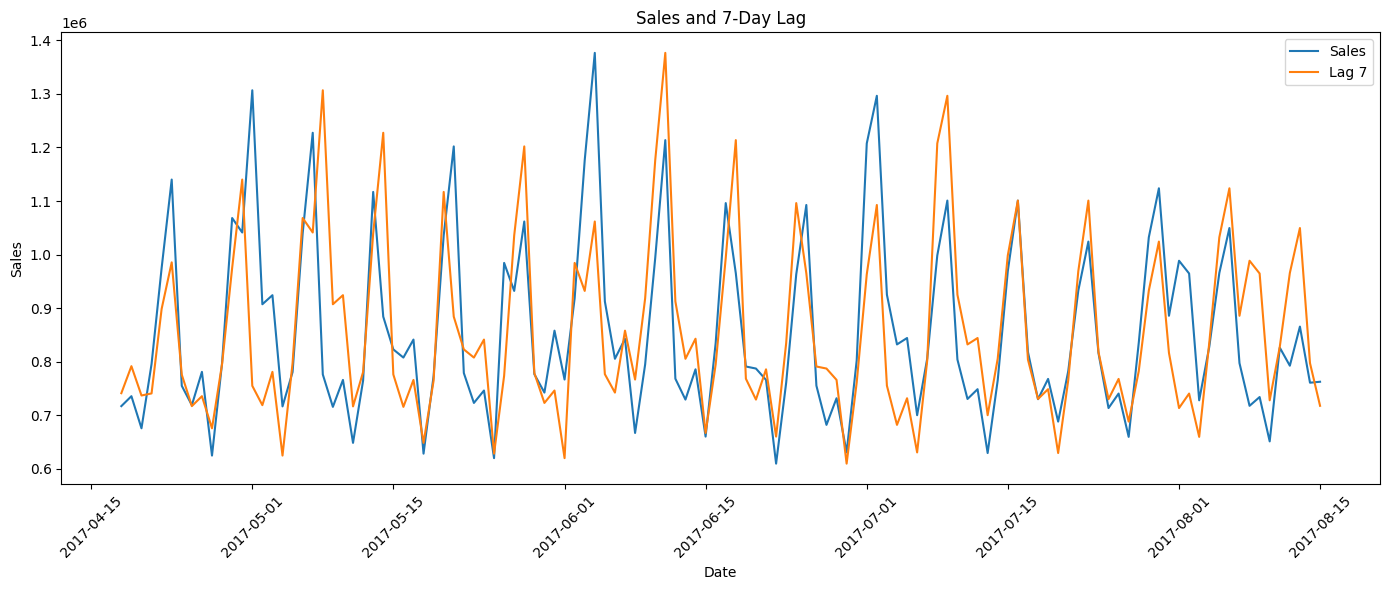

In [54]:
plot_data = feature_data.tail(120)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_data["date"],
    plot_data["sales"],
    label="Sales"
)

plt.plot(
    plot_data["date"],
    plot_data["lag_7"],
    label="Lag 7"
)

plt.title("Sales and 7-Day Lag")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../images/10_lag_feature_example.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 26. Rolling Feature Example

Rolling averages summarize recent demand and provide a smoother representation of the historical sales pattern.

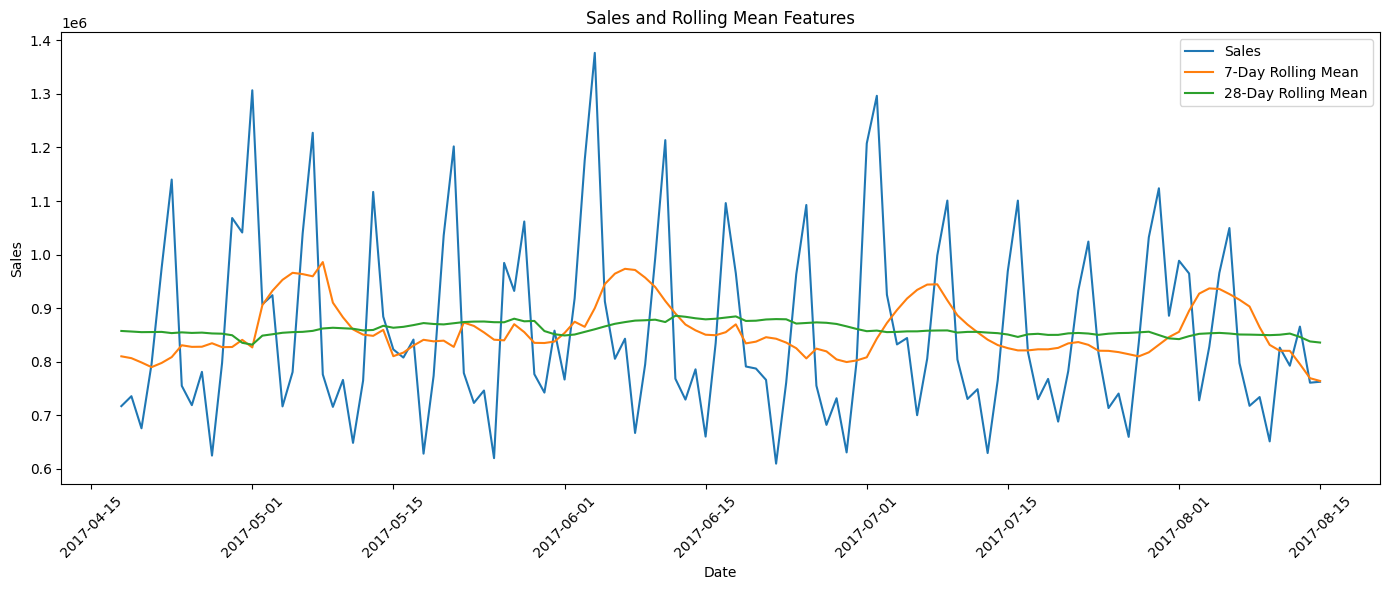

In [55]:
plot_data = feature_data.tail(120)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_data["date"],
    plot_data["sales"],
    label="Sales"
)

plt.plot(
    plot_data["date"],
    plot_data["rolling_mean_7"],
    label="7-Day Rolling Mean"
)

plt.plot(
    plot_data["date"],
    plot_data["rolling_mean_28"],
    label="28-Day Rolling Mean"
)

plt.title("Sales and Rolling Mean Features")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../images/11_rolling_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 27. Fourier Feature Example

The Fourier terms create smooth repeating cycles that represent weekly and annual seasonal behavior.

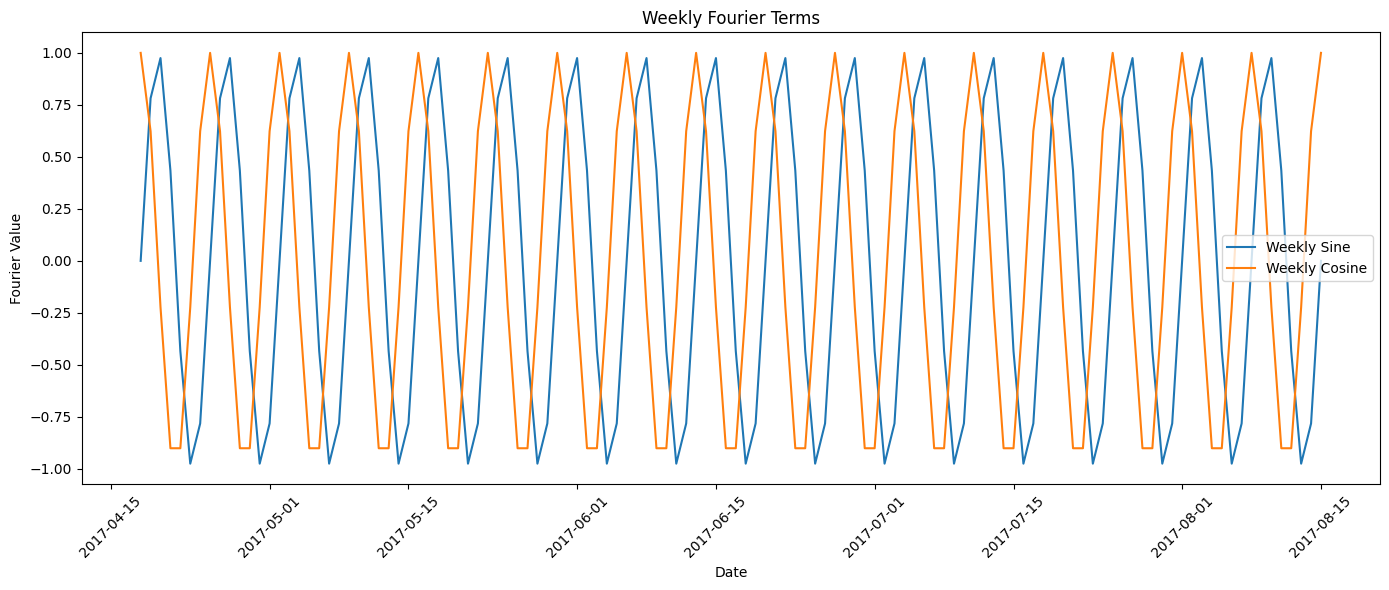

In [56]:
plot_data = feature_data.tail(120)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_data["date"],
    plot_data["weekly_sin_1"],
    label="Weekly Sine"
)

plt.plot(
    plot_data["date"],
    plot_data["weekly_cos_1"],
    label="Weekly Cosine"
)

plt.title("Weekly Fourier Terms")
plt.xlabel("Date")
plt.ylabel("Fourier Value")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../images/12_fourier_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 28. Final Feature Table

The engineered dataset is assembled into a single table containing the target and all temporal forecasting features.

Rows that cannot have complete lag or rolling information are removed from the training feature set.

The original missing Christmas dates are not treated as observed sales.

In [57]:
lag_columns = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28"
]

rolling_columns = [
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_std_14",
    "rolling_std_28"
]

fourier_columns = [
    "weekly_sin_1",
    "weekly_cos_1",
    "weekly_sin_2",
    "weekly_cos_2",
    "annual_sin_1",
    "annual_cos_1",
    "annual_sin_2",
    "annual_cos_2"
]

calendar_columns = [
    "day_of_week",
    "day_of_month",
    "week_of_year",
    "month",
    "quarter",
    "year",
    "is_weekend"
]

holiday_columns = [
    "holiday_event_count",
    "is_holiday_or_event",
    "is_national_holiday",
    "is_local_holiday"
]

promotion_columns = [
    "onpromotion",
    "is_promotion_day"
]

In [58]:
feature_columns = (
    lag_columns
    + rolling_columns
    + fourier_columns
    + calendar_columns
    + holiday_columns
    + promotion_columns
)

In [59]:
model_data = feature_data[
    ["date", "sales"] + feature_columns
].copy()

In [60]:
model_data = model_data.dropna(
    subset=["sales"] + lag_columns + rolling_columns
)

In [61]:
print("Rows with missing sales:", model_data["sales"].isna().sum())
print("Rows with missing features:", model_data[feature_columns].isna().sum().sum())

Rows with missing sales: 0
Rows with missing features: 0


In [62]:
model_data.shape

(1544, 33)

In [63]:
model_data.head()

,date,sales,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,rolling_std_7,...,month,quarter,year,is_weekend,holiday_event_count,is_holiday_or_event,is_national_holiday,is_local_holiday,onpromotion,is_promotion_day
28,2013-01-29,264488.818076,285460.169953,296214.728983,299129.549954,2511.618999,320916.224872,330877.422002,339672.163349,71044.389805,...,1,1,2013,0,0.0,0.0,0.0,0.0,0.0,0
29,2013-01-30,281061.127052,264488.818076,283258.453032,318347.913946,496092.417944,316383.951885,328403.084010,349028.491888,73839.837696,...,1,1,2013,0,0.0,0.0,0.0,0.0,0.0,0
30,2013-01-31,271254.217996,281061.127052,247245.690995,267498.515975,361461.231124,316070.048174,325739.742089,341348.802928,74008.606838,...,1,1,2013,0,0.0,0.0,0.0,0.0,0.0,0
31,2013-02-01,369402.055266,271254.217996,290022.771930,296130.850028,354459.677093,319499.837745,326008.006519,338127.123887,70773.071168,...,2,1,2013,0,0.0,0.0,0.0,0.0,0.0,0
32,2013-02-02,518887.462705,369402.055266,413799.767975,432459.852021,477350.121229,330839.735365,331241.664036,338660.780251,71617.207631,...,2,1,2013,1,0.0,0.0,0.0,0.0,0.0,0


## 29. Leakage Check

The feature construction is checked to make sure target-based features use only previous observations.

Lag features are created with `shift()`, while rolling statistics are calculated after shifting the sales series by one day.

This means the current day's sales value is not used to create its own prediction features.

In [64]:
check_date = pd.Timestamp("2017-08-15")

feature_data.loc[
    feature_data["date"] == check_date,
    [
        "date",
        "sales",
        "lag_1",
        "lag_7",
        "rolling_mean_7",
        "rolling_std_7"
    ]
]

,date,sales,lag_1,lag_7,rolling_mean_7,rolling_std_7
1687,2017-08-15,762661.935939,760922.406081,717766.349106,764122.753677,71601.9972


In [65]:
assert feature_data["lag_1"].equals(
    feature_data["sales"].shift(1)
)

In [66]:
expected_rolling_mean_7 = (
    feature_data["sales"]
    .shift(1)
    .rolling(7, min_periods=7)
    .mean()
)

assert np.allclose(
    feature_data["rolling_mean_7"].fillna(-1),
    expected_rolling_mean_7.fillna(-1)
)

## 30. Feature Relationships

The correlations between selected forecasting features and daily sales are reviewed to understand how the engineered variables relate to the target.

Correlation is used here for exploration only and does not determine which features will be used in the final model.

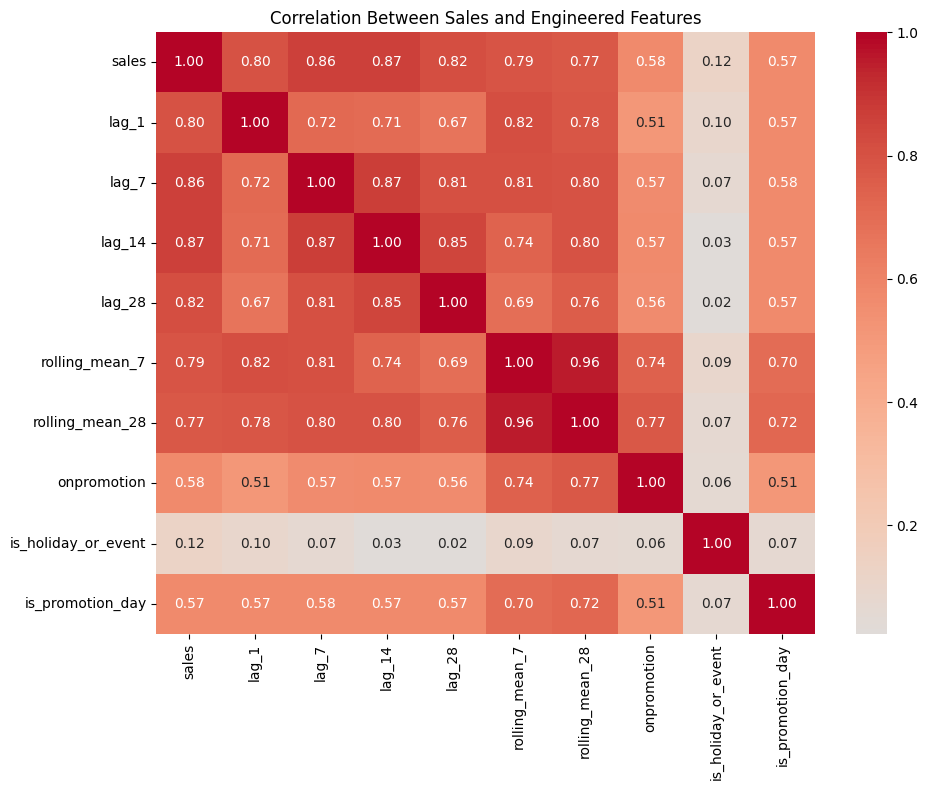

In [67]:
correlation_columns = [
    "sales",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "onpromotion",
    "is_holiday_or_event",
    "is_promotion_day"
]

correlation_matrix = model_data[
    correlation_columns
].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Sales and Engineered Features")
plt.tight_layout()

plt.savefig(
    "../images/13_feature_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Part 02 Findings

Temporal features were created to capture short-term demand patterns, weekly and annual seasonality, calendar effects, holiday and event effects, and promotion activity.

Lag features for 1, 7, 14, and 28 days were created from previous sales observations. These features provide the future models with information about recent and recurring demand.

Rolling means and standard deviations were created using 7-, 14-, and 28-day windows. The sales series was shifted by one day before the rolling calculations so that the current day's sales was not included in its own prediction features.

Calendar features were added for day of week, day of month, week of year, month, quarter, year, and weekend status.

Holiday and event indicators were created from the holiday dataset, including a general holiday/event indicator and national and local holiday indicators.

Promotion information was retained through the daily promotion count and a binary promotion-day indicator.

Weekly and annual Fourier terms were created using sine and cosine functions. The Fourier terms are based only on the calendar date and do not use sales information.

The feature table was constructed using calendar-day spacing so that lag 7 represents the value seven days earlier rather than simply the seventh previous observed row.

The main leakage check confirmed that lag and rolling features use only previous sales observations. No future target values are used in their construction.

These engineered features provide the foundation for the machine-learning forecasting model that will be developed later in the project.

## Leakage Prevention Rules Used

The following rules are applied throughout the project:

1. Lag features use previous observations only.
2. Rolling features use `shift(1)` before calculating the rolling window.
3. Future sales values are never used to create historical training features.
4. Calendar features are derived directly from the date.
5. Holiday and promotion indicators use information associated with the corresponding date.
6. Model validation in later stages will preserve chronological order and will not use random shuffling.